# E-Commerce Analytics Dashboard

**Author:** Raghav Dixit  
**Dataset:** UCI Online Retail Dataset (541,909 rows)  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · SQLite · Looker Studio

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

df = pd.read_csv(
    r"C:\Users\Master Mind Computer\Downloads\data.csv\data.csv",
    encoding="latin1"
)

## 2. Initial Data Inspection

In [2]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [6]:
df.tail(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541899,581587,22726,ALARM CLOCK BAKELIKE GREEN,4,12/9/2011 12:50,3.75,12680.0,France
541900,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,12/9/2011 12:50,3.75,12680.0,France
541901,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,12/9/2011 12:50,1.95,12680.0,France
541902,581587,22629,SPACEBOY LUNCH BOX,12,12/9/2011 12:50,1.95,12680.0,France
541903,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,12/9/2011 12:50,4.15,12680.0,France
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [9]:
df = df.dropna(subset=['CustomerID'])

df = df[df['Quantity'] > 0]

df = df[df['UnitPrice'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(f'Cleaned dataset shape: {df.shape}')

Cleaned dataset shape: (397884, 9)


In [10]:
import re

df.columns = [
    re.sub(r'(?<!^)([A-Z])', r'_\1', col)
    for col in df.columns
]
df.columns

Index(['Invoice_No', 'Stock_Code', 'Description', 'Quantity', 'Invoice_Date',
       'Unit_Price', 'Customer_I_D', 'Country', 'Total_Price'],
      dtype='str')

In [11]:
df.rename(columns={'Customer_I_D': 'Customer_ID'}, inplace=True)

df.columns = df.columns.str.lower()

df.columns

Index(['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date',
       'unit_price', 'customer_id', 'country', 'total_price'],
      dtype='str')

In [12]:
df['month'] = df['invoice_date'].dt.to_period('M').dt.to_timestamp()

df['day_of_week'] = df['invoice_date'].dt.day_name()
df['hour'] = df['invoice_date'].dt.hour

df.dtypes

invoice_no                 str
stock_code                 str
description                str
quantity                 int64
invoice_date    datetime64[us]
unit_price             float64
customer_id            float64
country                    str
total_price            float64
month           datetime64[us]
day_of_week                str
hour                     int32
dtype: object

In [13]:
print('Start date:', df['invoice_date'].min())
print('End date  :', df['invoice_date'].max())

Start date: 2010-12-01 08:26:00
End date  : 2011-12-09 12:50:00


In [14]:
country_revenue = df.groupby('country')['total_price'].sum().sort_values(ascending=False)
country_revenue

country
United Kingdom          7308391.554
Netherlands              285446.340
EIRE                     265545.900
Germany                  228867.140
France                   209024.050
Australia                138521.310
Spain                     61577.110
Switzerland               56443.950
Belgium                   41196.340
Sweden                    38378.330
Japan                     37416.370
Norway                    36165.440
Portugal                  33439.890
Finland                   22546.080
Singapore                 21279.290
Channel Islands           20450.440
Denmark                   18955.340
Italy                     17483.240
Cyprus                    13590.380
Austria                   10198.680
Poland                     7334.650
Israel                     7221.690
Greece                     4760.520
Iceland                    4310.000
Canada                     3666.380
USA                        3580.390
Malta                      2725.590
Unspecified         

In [15]:
top_selling_product = df.groupby('description')['quantity'].sum().sort_values(ascending=False)
top_selling_product.head(10)

description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: quantity, dtype: int64

In [16]:
monthly_revenue = df.groupby(
    df['invoice_date'].dt.to_period('M')
)['total_price'].sum()
monthly_revenue

invoice_date
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: total_price, dtype: float64

In [17]:
order_value = df.groupby('invoice_no')['total_price'].sum()
avg_order_value = order_value.mean()
print(f'Average Order Value: £{avg_order_value:.2f}')
order_value

Average Order Value: £480.87


invoice_no
536365    139.12
536366     22.20
536367    278.73
536368     70.05
536369     17.85
           ...  
581583    124.60
581584    140.64
581585    329.05
581586    339.20
581587    249.45
Name: total_price, Length: 18532, dtype: float64

In [18]:
monthly_customer = df.groupby('month')['customer_id'].nunique()
monthly_customer

month
2010-12-01     885
2011-01-01     741
2011-02-01     758
2011-03-01     974
2011-04-01     856
2011-05-01    1056
2011-06-01     991
2011-07-01     949
2011-08-01     935
2011-09-01    1266
2011-10-01    1364
2011-11-01    1664
2011-12-01     615
Name: customer_id, dtype: int64

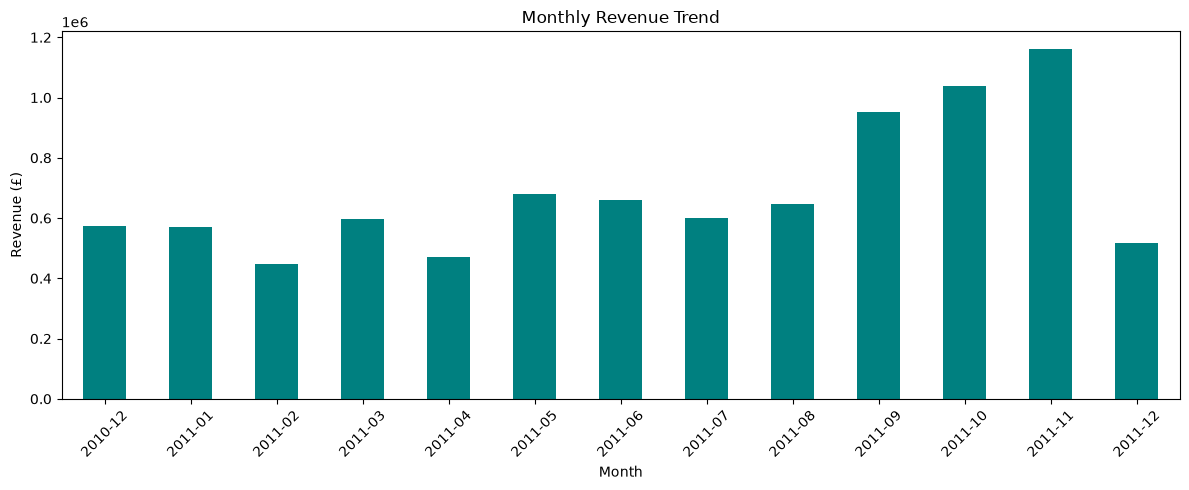

In [28]:
monthly_revenue.plot(kind='bar', figsize=(12, 5), color='teal')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/monthly_revenue1.png', dpi=150)
plt.show()

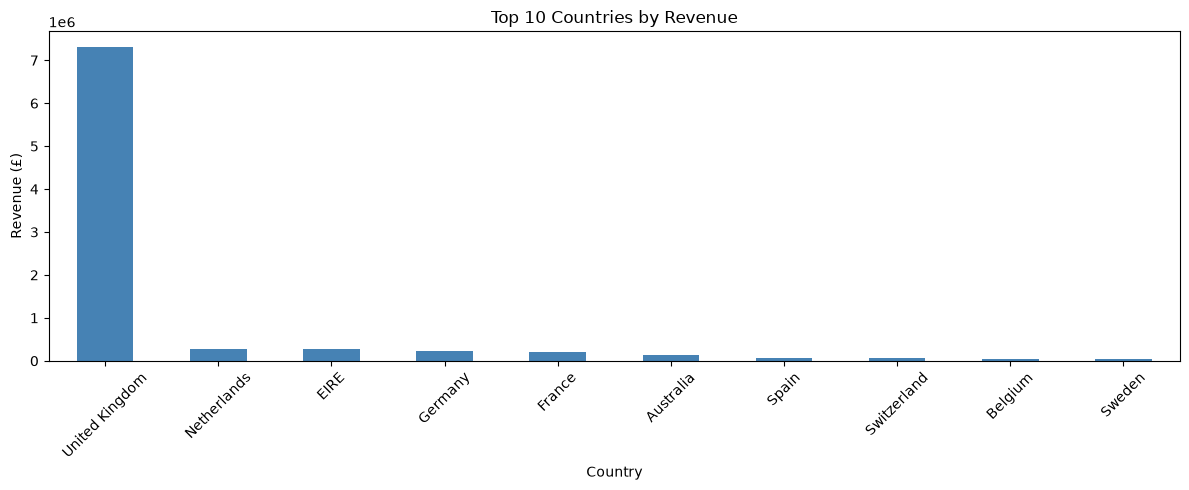

In [20]:
country_revenue.head(10).plot(kind='bar', figsize=(12, 5), color='steelblue')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/country_revenue.png', dpi=150)
plt.show()

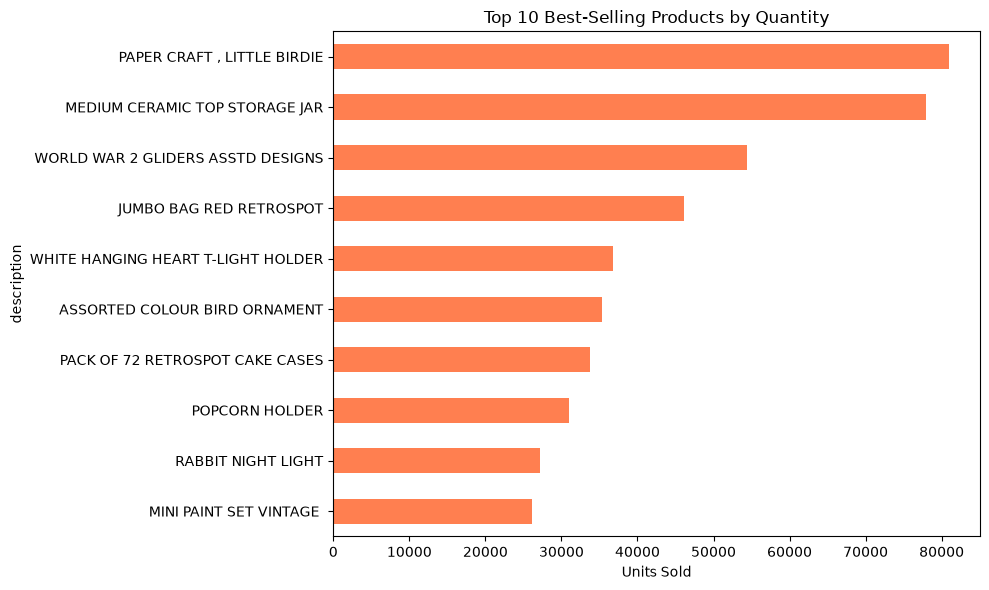

In [33]:
top_selling_product.head(10).sort_values().plot(kind='barh', figsize=(10, 6), color='coral')
plt.title('Top 10 Best-Selling Products by Quantity')
plt.xlabel('Units Sold')
plt.tight_layout()
plt.savefig('charts/top_products.png', dpi=150)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

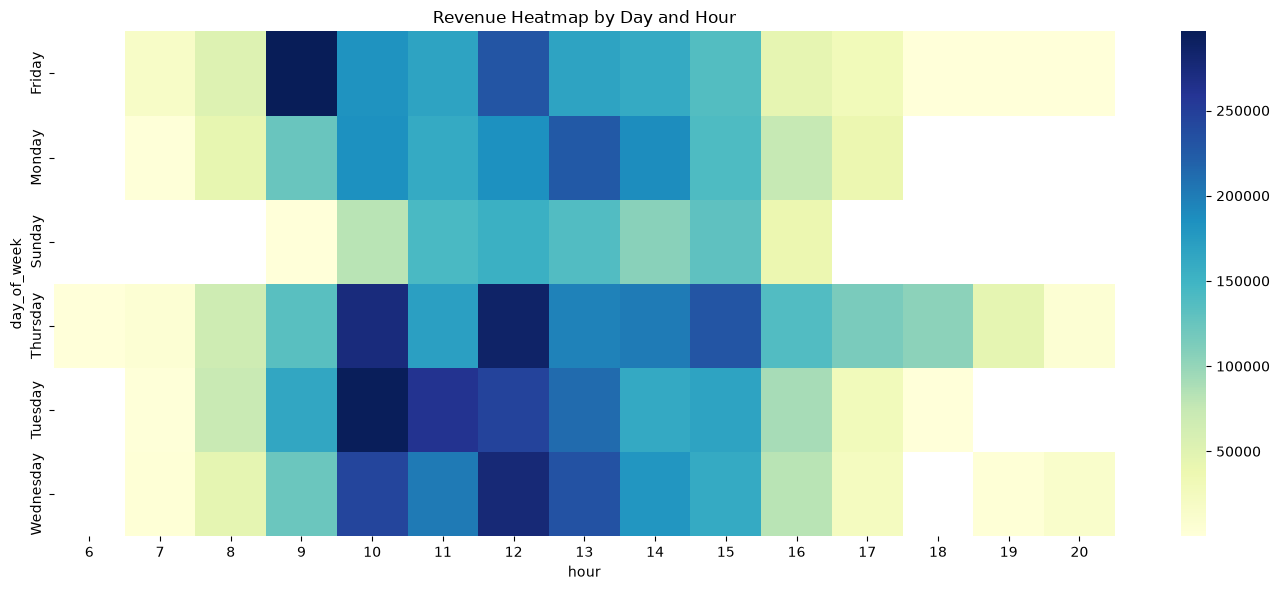

In [32]:
df['day_of_week'] = df['invoice_date'].dt.day_name()
df['hour']= df['invoice_date'].dt.hour
pivot = df.groupby(['day_of_week' , 'hour'])['total_price'].sum().unstack()

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title('Revenue Heatmap by Day and Hour')
plt.tight_layout()
plt.savefig('charts/revenue_heatmap_by_day_and_hour.png', dpi=300)
plt.show

In [23]:
conn = sqlite3.connect('ecommerce.db')
df.to_sql('retail_data', conn, if_exists='replace', index=False)
print('Data loaded into SQLite successfully')

Data loaded into SQLite successfully


In [24]:
query_1 = """
SELECT country,
       ROUND(SUM(total_price), 2) AS TotalRevenue,
       COUNT(DISTINCT customer_id) AS UniqueCustomers
FROM retail_data
GROUP BY country
ORDER BY TotalRevenue DESC
LIMIT 5
"""
pd.read_sql_query(query_1, conn)

,country,TotalRevenue,UniqueCustomers
0,United Kingdom,7308391.55,3920
1,Netherlands,285446.34,9
2,EIRE,265545.90,3
3,Germany,228867.14,94
4,France,209024.05,87


In [25]:
query_2 = """
SELECT strftime('%Y-%m', month) AS Month,
       ROUND(SUM(total_price), 2) AS Revenue
FROM retail_data
GROUP BY Month
ORDER BY Month
"""
pd.read_sql_query(query_2, conn)

,Month,Revenue
0,2010-12,572713.89
1,2011-01,569445.04
2,2011-02,447137.35
3,2011-03,595500.76
4,2011-04,469200.36
5,2011-05,678594.56
6,2011-06,661213.69
7,2011-07,600091.01
8,2011-08,645343.90
9,2011-09,952838.38


In [26]:
query_3 = """
SELECT customer_id AS Customer,
       COUNT(DISTINCT strftime('%Y-%m', month)) AS ActiveMonths
FROM retail_data
GROUP BY customer_id
HAVING ActiveMonths > 1
ORDER BY ActiveMonths DESC
LIMIT 10
"""
pd.read_sql_query(query_3, conn)

,Customer,ActiveMonths
0,18109.0,13
1,17949.0,13
2,17841.0,13
3,17757.0,13
4,17735.0,13
5,17677.0,13
6,17675.0,13
7,17576.0,13
8,17511.0,13
9,17428.0,13


In [34]:
import os
os.makedirs('charts', exist_ok=True)

country_revenue.reset_index().to_csv('country_revenue.csv', index=False)
monthly_revenue.reset_index().to_csv('monthly_revenue.csv', index=False)
monthly_customer.reset_index().to_csv('monthly_customer.csv', index=False)
top_selling_product.reset_index().to_csv('top_selling_product.csv', index=False)
df.to_csv('cleaned_retail.csv', index=False)
